In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/SP500_Historical_Data.csv")

# Show first 5 rows
df.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,A,2000-01-03,47.07,47.18,40.27,43.04,43.04,4674353
1,A,2000-01-04,40.72,41.17,38.70,39.75,39.75,4765083
2,A,2000-01-05,39.60,39.75,36.05,37.28,37.28,5758642
3,A,2000-01-06,36.83,37.06,34.74,35.86,35.86,2534434
4,A,2000-01-07,35.30,39.41,35.27,38.85,38.85,2819626


In [2]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print(df.columns)

# Dataset info
df.info()

Shape: (2703531, 8)
Index(['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close',
       'Volume'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2703531 entries, 0 to 2703530
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Ticker     object 
 1   Date       object 
 2   Open       float64
 3   High       float64
 4   Low        float64
 5   Close      float64
 6   Adj Close  float64
 7   Volume     int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 165.0+ MB


In [3]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2.703531e+06,2.703531e+06,2.703531e+06,2.703531e+06,2.703531e+06,2.703531e+06
mean,7.276919e+01,7.362523e+01,7.189230e+01,7.277753e+01,7.277753e+01,8.716755e+06
std,1.478146e+02,1.494931e+02,1.461006e+02,1.478435e+02,1.478435e+02,4.919465e+07
min,3.000000e-02,3.000000e-02,3.000000e-02,3.000000e-02,3.000000e-02,0.000000e+00
25%,1.615000e+01,1.638000e+01,1.592000e+01,1.615000e+01,1.615000e+01,9.281085e+05
50%,3.399000e+01,3.440000e+01,3.357000e+01,3.399000e+01,3.399000e+01,2.211500e+06
75%,7.705000e+01,7.792000e+01,7.618000e+01,7.707000e+01,7.707000e+01,5.423200e+06
max,5.793920e+03,5.818240e+03,5.687240e+03,5.794840e+03,5.794840e+03,9.230856e+09


In [4]:
df.isnull().sum()

Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df = df.drop_duplicates()

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
print(df['Date'].dtype)

datetime64[ns]


In [9]:
df = df.sort_values(by=['Ticker', 'Date'])

In [10]:
print(df.columns)

Index(['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close',
       'Volume'],
      dtype='object')


In [11]:
df.to_csv("../data/cleaned_sp500.csv", index=False)

In [12]:
df['Ticker'].nunique()

472

In [13]:
df['Ticker'].unique()[:10]

array(['A', 'AAL', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE',
       'ADI'], dtype=object)

In [14]:
print(df['Date'].min())
print(df['Date'].max())

2000-01-03 00:00:00
2026-02-20 00:00:00


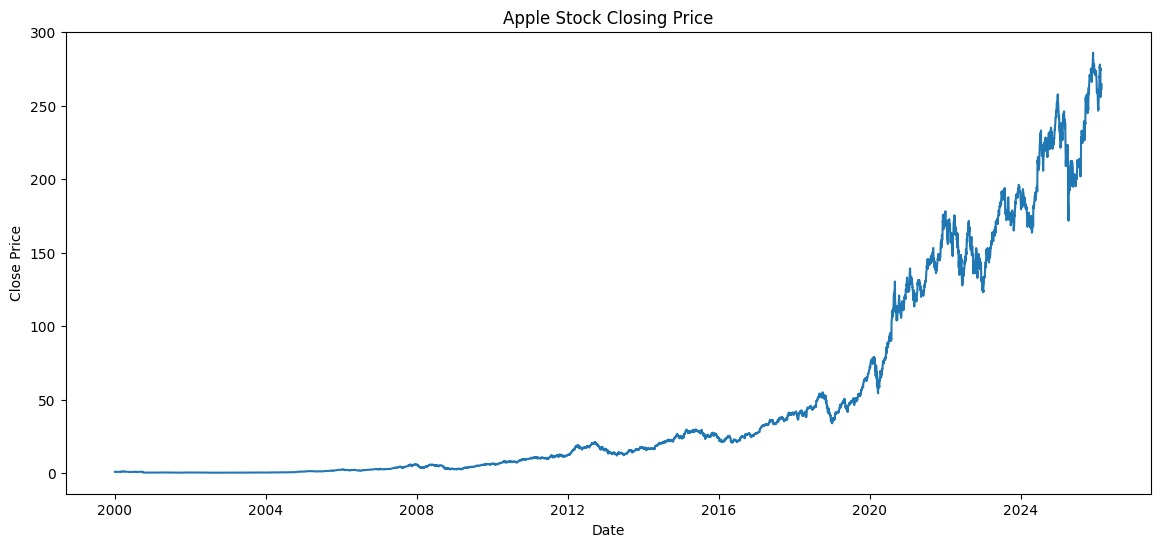

In [15]:
import matplotlib.pyplot as plt

# Filter Apple stock
apple = df[df['Ticker'] == 'AAPL']

# Plot closing price
plt.figure(figsize=(14,6))

plt.plot(apple['Date'], apple['Close'])

plt.title("Apple Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()